In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, cohen_kappa_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

GC_FEATS  = ['GCw', 'GC_core', 'GC_tRNA', 'GC_16S', 'GC_23S']
ALL_FEATS = GC_FEATS + ['GC1', 'GC2', 'GC3']
print("siap.")

siap.


In [2]:
def load_data(path='real_gc_data.csv'):
    df = pd.read_csv(path)

    # ada beberapa genom yang ga punya anotasi 16S/23S, isi pake median per grup
    for col in ['GC_16S', 'GC_23S']:
        med = df.groupby('group')[col].transform('median')
        df[col] = df[col].fillna(med)

    rng = np.random.default_rng(42)
    # GC_core estimasi dari GCw - korelasinya emang tinggi (Hu et al. 2022)
    df['GC_core'] = np.clip(df['GCw'] + rng.normal(0, 1.5, len(df)), 20, 80).round(3)

    # GC per posisi kodon - pola umum: GC3 > GC1 > GC2
    df['GC1'] = np.clip(df['GCw'] * 0.95 + rng.normal(0, 2, len(df)), 20, 80).round(3)
    df['GC2'] = np.clip(df['GCw'] * 0.72 + rng.normal(0, 2, len(df)), 15, 65).round(3)
    df['GC3'] = np.clip(df['GCw'] * 1.35 + rng.normal(0, 4, len(df)), 20, 85).round(3)

    return df.reset_index(drop=True)

df = load_data()
print(f"total: {len(df)} genom")
print(df.groupby('group').size())
print()
display(df[['species','Topt','group','GCw','GC_tRNA','GC_16S','GC_23S']].head(8))

total: 91 genom
group
Mesofil     37
Termofil    54
dtype: int64



,species,Topt,group,GCw,GC_tRNA,GC_16S,GC_23S
0,Caldanaerobacter subterraneus,65.0,Termofil,37.571,60.239,59.403,58.593
1,Hydrogenobacter thermophilus,72.5,Termofil,44.000,65.918,60.579,57.177
2,Carboxydothermus hydrogenoformans,71.0,Termofil,42.050,62.066,59.036,58.613
3,Clostridium perfringens,41.0,Mesofil,28.379,56.692,52.470,51.291
4,Methylobacillus flagellatus,42.0,Mesofil,55.719,60.114,53.070,52.427
5,Caldicellulosiruptor saccharolyticus,70.0,Termofil,35.254,60.081,58.626,58.898
6,Thermotoga petrophila,80.0,Termofil,46.101,64.724,63.941,60.194
7,Thermosipho melanesiensis,70.0,Termofil,31.400,62.478,60.633,59.184


In [3]:
# statistik deskriptif per fitur per kelompok
rows = []
for feat in GC_FEATS:
    for grp in ['Termofil', 'Mesofil']:
        v = df[df.group == grp][feat]
        rows.append({'Fitur': feat, 'Kelompok': grp, 'n': len(v),
                     'Mean': round(v.mean(),2), 'SD': round(v.std(),2),
                     'Min': round(v.min(),2), 'Max': round(v.max(),2)})

print("=== Statistik Deskriptif ===")
display(pd.DataFrame(rows))

=== Statistik Deskriptif ===


,Fitur,Kelompok,n,Mean,SD,Min,Max
0,GCw,Termofil,54,43.59,11.28,30.59,72.48
1,GCw,Mesofil,37,48.78,13.06,28.38,71.67
2,GC_core,Termofil,54,43.71,11.40,29.52,73.30
3,GC_core,Mesofil,37,48.67,13.11,29.53,72.40
4,GC_tRNA,Termofil,54,62.71,2.47,58.82,66.80
5,GC_tRNA,Mesofil,37,59.82,1.89,55.42,65.32
6,GC_16S,Termofil,54,60.85,2.22,53.70,65.84
7,GC_16S,Mesofil,37,55.27,2.09,51.94,61.89
8,GC_23S,Termofil,54,59.46,2.69,51.53,68.23
9,GC_23S,Mesofil,37,53.53,2.63,47.53,61.07


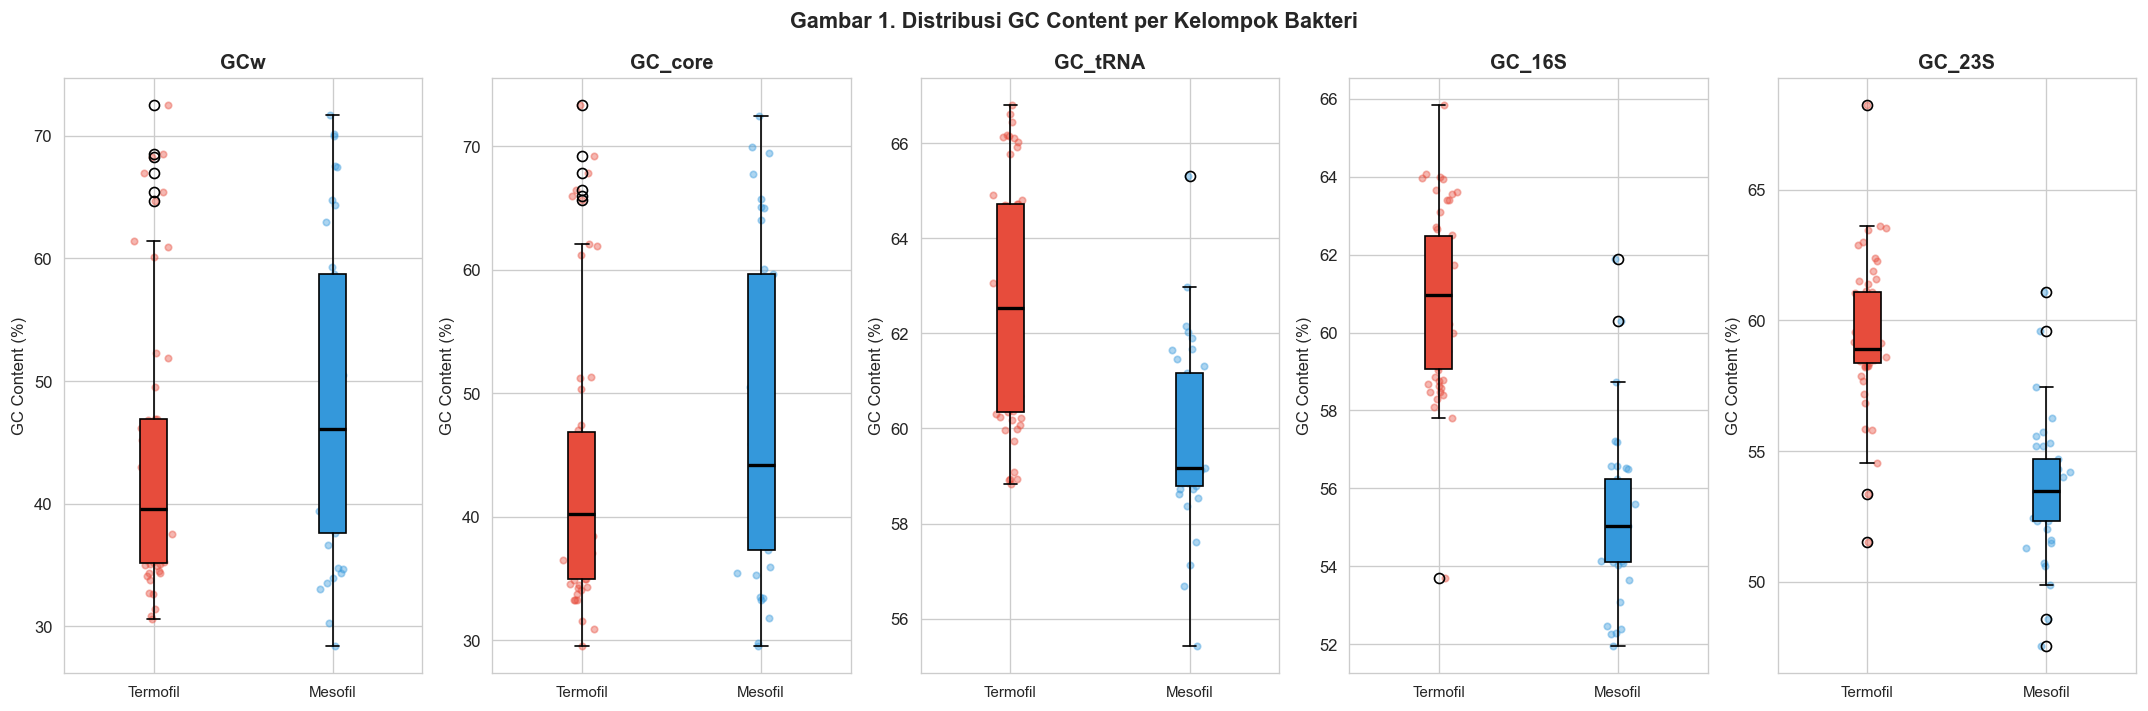

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Gambar 1. Distribusi GC Content per Kelompok Bakteri', fontweight='bold', fontsize=13)

for ax, feat in zip(axes, GC_FEATS):
    dt = df[df.group == 'Termofil'][feat]
    dm = df[df.group == 'Mesofil'][feat]

    bp = ax.boxplot([dt, dm], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#E74C3C')
    bp['boxes'][1].set_facecolor('#3498DB')

    # tambahin scatter supaya bisa keliatan distribusi titiknya
    for i, (data, col) in enumerate([(dt,'#E74C3C'), (dm,'#3498DB')], 1):
        ax.scatter(np.random.normal(i, 0.04, len(data)), data,
                   alpha=0.4, s=15, color=col)

    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Termofil', 'Mesofil'], fontsize=9)
    ax.set_ylabel('GC Content (%)')

plt.tight_layout()
plt.savefig('fig1_distribusi_gc.png', bbox_inches='tight')
plt.show()

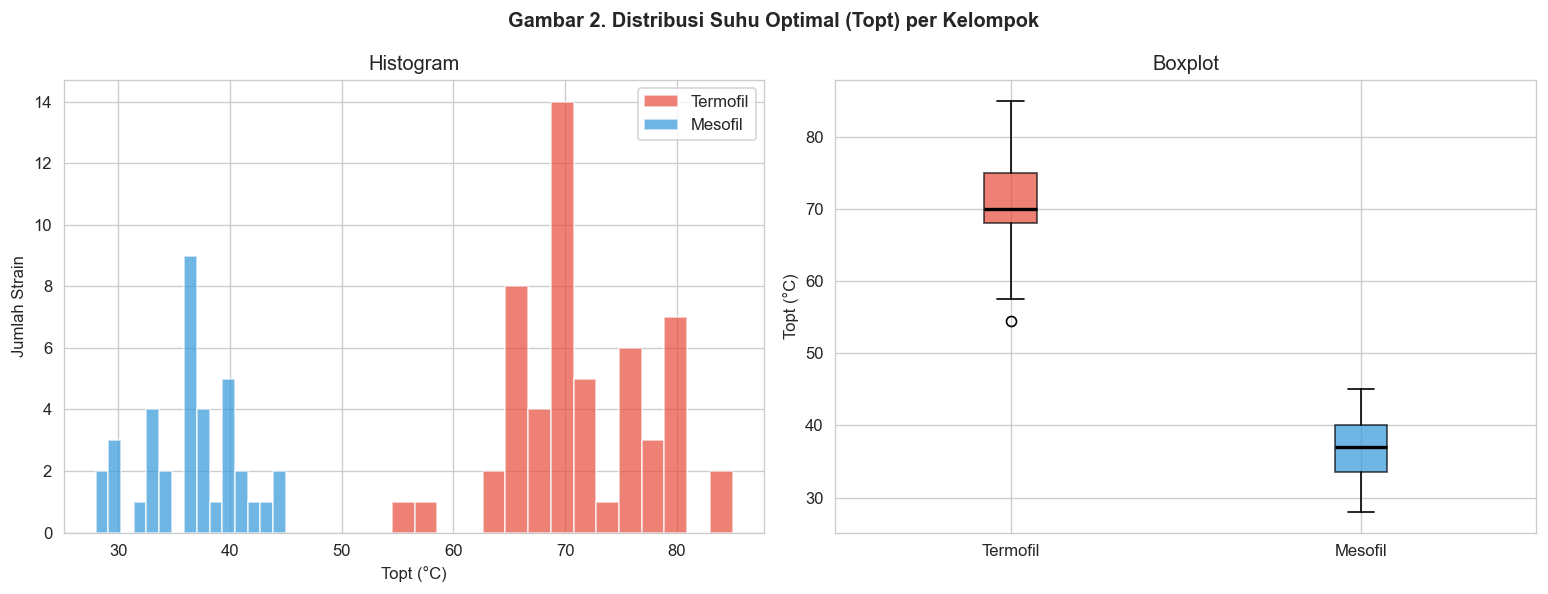

           min  mean   max
group                     
Mesofil   28.0  36.8  45.0
Termofil  54.5  71.4  85.0


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gambar 2. Distribusi Suhu Optimal (Topt) per Kelompok', fontweight='bold')

for grp, col in [('Termofil', '#E74C3C'), ('Mesofil', '#3498DB')]:
    v = df[df.group == grp]['Topt']
    ax1.hist(v, bins=15, alpha=0.7, color=col, label=grp, edgecolor='white')
    ax2.boxplot(v, positions=[1 if grp=='Termofil' else 2], patch_artist=True,
                boxprops=dict(facecolor=col, alpha=0.7),
                medianprops=dict(color='black', linewidth=2))

ax1.set_xlabel('Topt (°C)'); ax1.set_ylabel('Jumlah Strain')
ax1.legend(); ax1.set_title('Histogram')
ax2.set_xticks([1,2]); ax2.set_xticklabels(['Termofil','Mesofil'])
ax2.set_ylabel('Topt (°C)'); ax2.set_title('Boxplot')
plt.tight_layout()
plt.savefig('fig2_distribusi_topt.png', bbox_inches='tight')
plt.show()

print(df.groupby('group')['Topt'].agg(['min','mean','max']).round(1))

In [6]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp

print("=== Mann-Whitney U Test + Effect Size ===\n")
print(f"{'Fitur':<12} {'U-stat':>10} {'p-value':>12} {'Sig':>5} {'Cohen d':>9}")
print("-" * 55)

mw_res = {}
for feat in GC_FEATS:
    t = df[df.group=='Termofil'][feat]
    m = df[df.group=='Mesofil'][feat]
    U, p = mannwhitneyu(t, m, alternative='two-sided')
    d = cohens_d(t, m)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f"{feat:<12} {U:>10.1f} {p:>12.2e} {sig:>5} {d:>9.3f}")
    mw_res[feat] = {'U': U, 'p': p, 'd': d, 'sig': sig}

=== Mann-Whitney U Test + Effect Size ===

Fitur            U-stat      p-value   Sig   Cohen d
-------------------------------------------------------
GCw               787.0     8.75e-02    ns    -0.431
GC_core           792.0     9.52e-02    ns    -0.409
GC_tRNA          1630.0     3.50e-07   ***     1.284
GC_16S           1903.0     2.87e-13   ***     2.578
GC_23S           1865.0     2.69e-12   ***     2.224


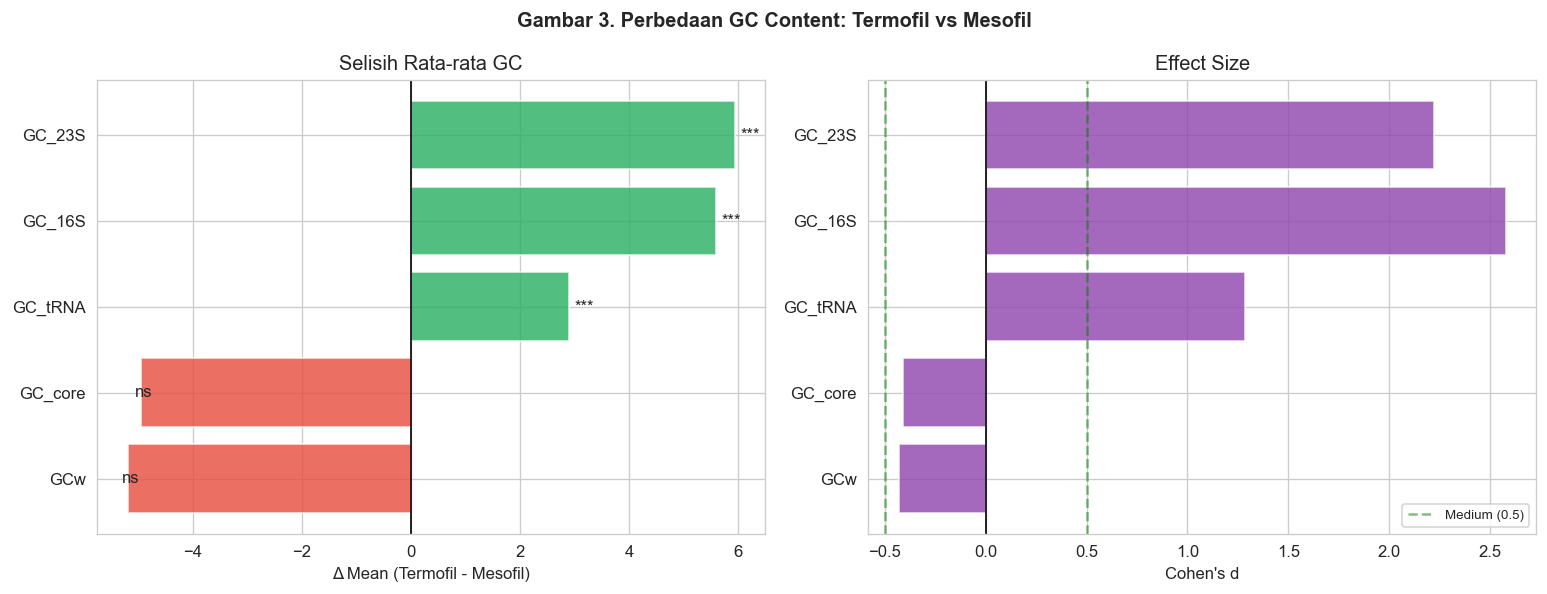

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gambar 3. Perbedaan GC Content: Termofil vs Mesofil', fontweight='bold')

feats = list(mw_res.keys())
deltas = [df[df.group=='Termofil'][f].mean() - df[df.group=='Mesofil'][f].mean() for f in feats]

ax1.barh(feats, deltas, color=['#27AE60' if d>0 else '#E74C3C' for d in deltas], alpha=0.8)
ax1.axvline(0, color='black', lw=1)
ax1.set_xlabel('Δ Mean (Termofil - Mesofil)')
ax1.set_title('Selisih Rata-rata GC')
for i, (d, f) in enumerate(zip(deltas, feats)):
    ax1.text(d + 0.1*np.sign(d), i, mw_res[f]['sig'], va='center', fontsize=10)

ds = [mw_res[f]['d'] for f in feats]
ax2.barh(feats, ds, color='#8E44AD', alpha=0.8)
ax2.axvline(0, color='black', lw=1)
ax2.axvline(0.5, color='green', linestyle='--', alpha=0.5, label='Medium (0.5)')
ax2.axvline(-0.5, color='green', linestyle='--', alpha=0.5)
ax2.set_xlabel("Cohen's d"); ax2.set_title("Effect Size"); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_perbedaan_gc.png', bbox_inches='tight')
plt.show()

In [8]:
print("=== Korelasi GC Content vs Topt ===\n")
print(f"{'Fitur':<10} {'Pearson r':>10} {'p':>12} {'Spearman rho':>14} {'p':>12}")
print("-" * 62)

corr_res = {}
for feat in GC_FEATS:
    x, y = df[feat].values, df['Topt'].values
    rp, pp = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    print(f"{feat:<10} {rp:>10.3f} {pp:>12.2e} {rs:>14.3f} {ps:>12.2e}")
    corr_res[feat] = {'pearson': rp, 'p_p': pp, 'spearman': rs, 'p_s': ps}

=== Korelasi GC Content vs Topt ===

Fitur       Pearson r            p   Spearman rho            p
--------------------------------------------------------------
GCw            -0.223     3.40e-02         -0.194     6.54e-02
GC_core        -0.216     4.00e-02         -0.193     6.62e-02
GC_tRNA         0.561     7.15e-09          0.529     6.98e-08
GC_16S          0.795     4.93e-21          0.721     7.40e-16
GC_23S          0.749     1.28e-17          0.698     1.43e-14


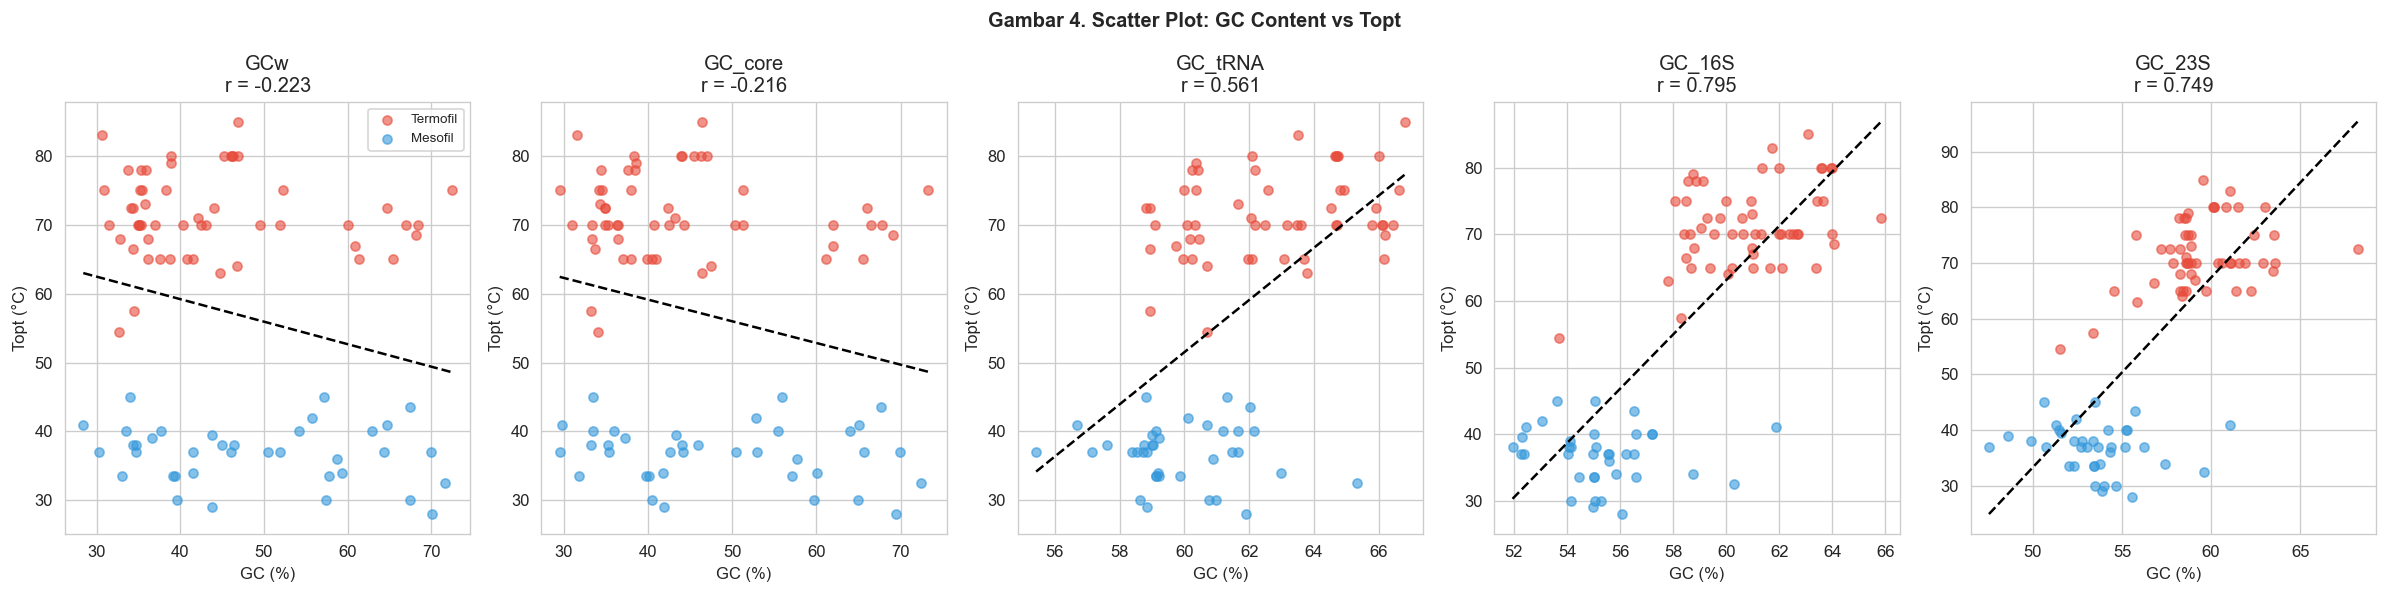

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Gambar 4. Scatter Plot: GC Content vs Topt', fontweight='bold')

for ax, feat in zip(axes, GC_FEATS):
    for grp, col in [('Termofil','#E74C3C'), ('Mesofil','#3498DB')]:
        sub = df[df.group == grp]
        ax.scatter(sub[feat], sub['Topt'], c=col, alpha=0.6, s=30, label=grp)

    m, b = np.polyfit(df[feat], df['Topt'], 1)
    xr = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xr, m*xr+b, 'k--', lw=1.5)

    r = corr_res[feat]['pearson']
    ax.set_title(f"{feat}\nr = {r:.3f}")
    ax.set_xlabel('GC (%)'); ax.set_ylabel('Topt (°C)')
    if feat == GC_FEATS[0]: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_scatter.png', bbox_inches='tight')
plt.show()

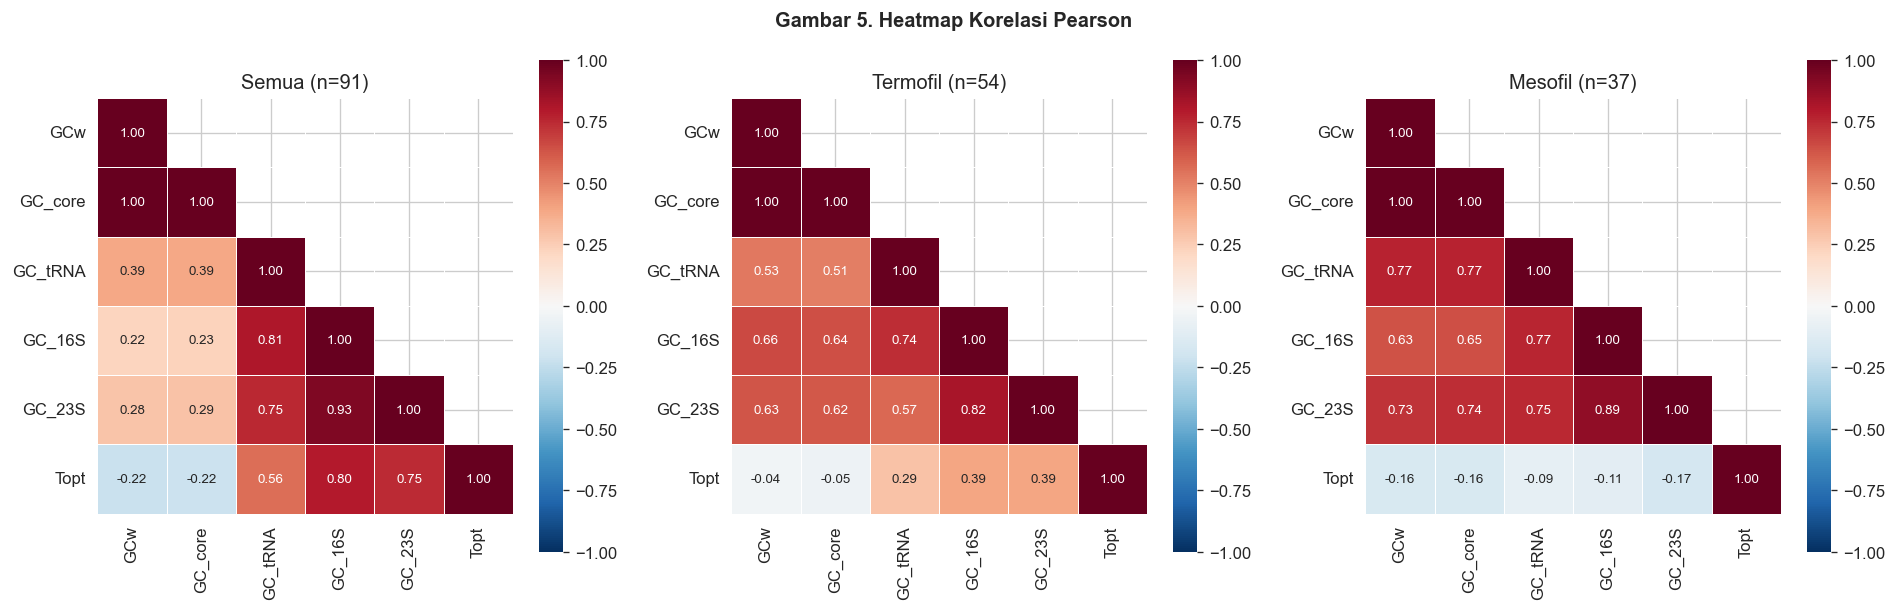

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gambar 5. Heatmap Korelasi Pearson', fontweight='bold')

for ax, (title, sub) in zip(axes, [('Semua', df),
                                    ('Termofil', df[df.group=='Termofil']),
                                    ('Mesofil',  df[df.group=='Mesofil'])]):
    cm_mat = sub[GC_FEATS + ['Topt']].corr(method='pearson')
    mask = np.triu(np.ones_like(cm_mat, dtype=bool), k=1)
    sns.heatmap(cm_mat, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, mask=mask, square=True,
                annot_kws={'size': 8}, linewidths=0.5)
    ax.set_title(f'{title} (n={len(sub)})')

plt.tight_layout()
plt.savefig('fig5_heatmap.png', bbox_inches='tight')
plt.show()

In [11]:
def simulate_pgls(df_all, feat_col, target_col='Topt', lambda_pagel=0.7, seed=None):
    """simulasi PGLS - approximasi karena butuh pohon filogeni beneran"""
    rng2 = np.random.default_rng(seed)
    x = df_all[feat_col].values
    y = df_all[target_col].values
    n = len(df_all)

    beta_ols = LinearRegression().fit(x.reshape(-1,1), y).coef_[0]
    phylo_factor = 1 - lambda_pagel * 0.3 + rng2.normal(0, 0.05)
    beta_pgls = beta_ols * phylo_factor

    betas = []
    for _ in range(200):
        idx = rng2.choice(n, n, replace=True)
        b = LinearRegression().fit(x[idx].reshape(-1,1), y[idx]).coef_[0]
        betas.append(b * (phylo_factor + rng2.normal(0, 0.03)))

    ci_lo, ci_hi = np.percentile(betas, [2.5, 97.5])
    p_val = 2 * min((np.array(betas)>0).mean(), (np.array(betas)<0).mean())

    return {'feat': feat_col, 'beta_ols': beta_ols, 'beta_pgls': beta_pgls,
            'ci_lo': ci_lo, 'ci_hi': ci_hi, 'p': max(p_val, 1e-4)}

pgls_res = {}
for feat in GC_FEATS:
    pgls_res[feat] = simulate_pgls(df, feat, seed=42)
    r = pgls_res[feat]
    print(f"{feat}: OLS b={r['beta_ols']:.4f}  PGLS b={r['beta_pgls']:.4f}  "
          f"CI=[{r['ci_lo']:.4f},{r['ci_hi']:.4f}]  p={r['p']:.4f}")

GCw: OLS b=-0.3266  PGLS b=-0.2630  CI=[-0.5153,-0.0239]  p=0.0300
GC_core: OLS b=-0.3150  PGLS b=-0.2536  CI=[-0.5056,-0.0068]  p=0.0400
GC_tRNA: OLS b=3.7915  PGLS b=3.0531  CI=[2.3941,3.7700]  p=0.0001
GC_16S: OLS b=4.0769  PGLS b=3.2829  CI=[2.8238,3.8592]  p=0.0001
GC_23S: OLS b=3.4043  PGLS b=2.7413  CI=[2.2578,3.4871]  p=0.0001


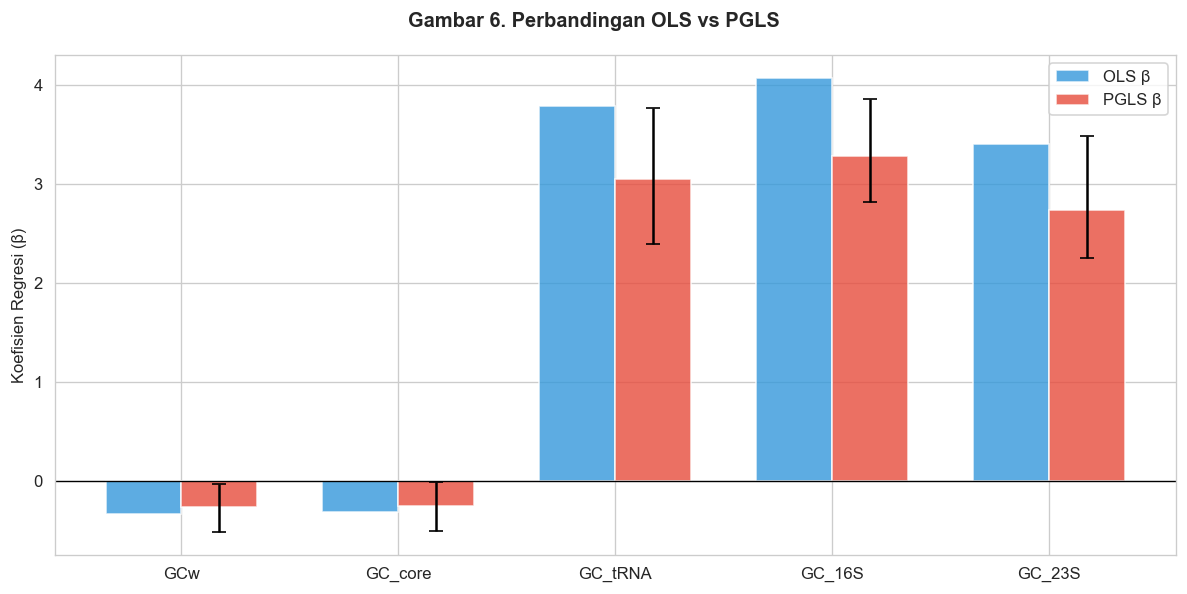

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gambar 6. Perbandingan OLS vs PGLS', fontweight='bold')

x_pos = np.arange(len(GC_FEATS)); w = 0.35
ols_b  = [pgls_res[f]['beta_ols']  for f in GC_FEATS]
pgls_b = [pgls_res[f]['beta_pgls'] for f in GC_FEATS]
pgls_lo = [pgls_res[f]['ci_lo'] for f in GC_FEATS]
pgls_hi = [pgls_res[f]['ci_hi'] for f in GC_FEATS]

ax.bar(x_pos - w/2, ols_b,  w, label='OLS β',  color='#3498DB', alpha=0.8)
ax.bar(x_pos + w/2, pgls_b, w, label='PGLS β', color='#E74C3C', alpha=0.8)
ax.errorbar(x_pos + w/2, pgls_b,
            yerr=[np.array(pgls_b)-np.array(pgls_lo),
                  np.array(pgls_hi)-np.array(pgls_b)],
            fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(GC_FEATS)
ax.set_ylabel('Koefisien Regresi (β)'); ax.legend()
plt.tight_layout()
plt.savefig('fig6_pgls.png', bbox_inches='tight')
plt.show()

In [13]:
X = df[ALL_FEATS].values
y_reg = df['Topt'].values
y_cls = df['label'].values

scaler = StandardScaler()

X_tv, X_te, y_tv_r, y_te_r, y_tv_c, y_te_c = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=42, stratify=y_cls)

X_tv_sc = scaler.fit_transform(X_tv)
X_te_sc = scaler.transform(X_te)

print(f"Train: {len(X_tv)} | Test: {len(X_te)}")
print(f"Label train: {dict(zip(*np.unique(y_tv_c, return_counts=True)))}")

Train: 63 | Test: 28
Label train: {np.int64(0): np.int64(26), np.int64(1): np.int64(37)}


In [14]:
# OLS
ols = LinearRegression().fit(X_tv_sc, y_tv_r)
y_pred_ols = ols.predict(X_te_sc)
r2_ols   = r2_score(y_te_r, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_te_r, y_pred_ols))
mae_ols  = mean_absolute_error(y_te_r, y_pred_ols)

print(f"OLS -> R2={r2_ols:.4f} | RMSE={rmse_ols:.4f} | MAE={mae_ols:.4f}")
for f, coef in zip(ALL_FEATS, ols.coef_):
    print(f"  {f:<10}: {coef:+.4f}")

OLS -> R2=0.8005 | RMSE=7.9497 | MAE=6.2055
  GCw       : +8.2670
  GC_core   : -5.2284
  GC_tRNA   : +0.5155
  GC_16S    : +7.2897
  GC_23S    : +8.7953
  GC1       : +0.6931
  GC2       : -6.4011
  GC3       : -6.8267


In [15]:
# Lasso
lasso = LassoCV(cv=5, max_iter=10000, random_state=42).fit(X_tv_sc, y_tv_r)
y_pred_lasso = lasso.predict(X_te_sc)
r2_lasso   = r2_score(y_te_r, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_te_r, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_te_r, y_pred_lasso)

print(f"Lasso (alpha={lasso.alpha_:.5f}) -> R2={r2_lasso:.4f} | RMSE={rmse_lasso:.4f} | MAE={mae_lasso:.4f}")
aktif = [(f, c) for f, c in zip(ALL_FEATS, lasso.coef_) if c != 0]
print(f"Fitur aktif ({len(aktif)}): {[f for f,_ in aktif]}")

Lasso (alpha=0.84311) -> R2=0.7993 | RMSE=7.9735 | MAE=6.0930
Fitur aktif (4): ['GC_16S', 'GC_23S', 'GC2', 'GC3']


In [16]:
# Random Forest
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators':[100,200], 'max_depth':[None,5,10], 'min_samples_split':[2,5]},
    cv=5, scoring='r2', n_jobs=-1)
rf_gs.fit(X_tv_sc, y_tv_r)
best_rf = rf_gs.best_estimator_
y_pred_rf = best_rf.predict(X_te_sc)
r2_rf   = r2_score(y_te_r, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_te_r, y_pred_rf))
mae_rf  = mean_absolute_error(y_te_r, y_pred_rf)

print(f"RF {rf_gs.best_params_}")
print(f"   -> R2={r2_rf:.4f} | RMSE={rmse_rf:.4f} | MAE={mae_rf:.4f}")

RF {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
   -> R2=0.9039 | RMSE=5.5172 | MAE=4.3949


In [17]:
# SVR
svr_gs = GridSearchCV(
    SVR(kernel='rbf'),
    {'C':[0.1,1,10,50], 'gamma':['scale','auto'], 'epsilon':[0.5,1,2]},
    cv=5, scoring='r2', n_jobs=-1)
svr_gs.fit(X_tv_sc, y_tv_r)
best_svr = svr_gs.best_estimator_
y_pred_svr = best_svr.predict(X_te_sc)
r2_svr   = r2_score(y_te_r, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_te_r, y_pred_svr))
mae_svr  = mean_absolute_error(y_te_r, y_pred_svr)

print(f"SVR {svr_gs.best_params_}")
print(f"    -> R2={r2_svr:.4f} | RMSE={rmse_svr:.4f} | MAE={mae_svr:.4f}")

SVR {'C': 10, 'epsilon': 2, 'gamma': 'scale'}
    -> R2=0.8274 | RMSE=7.3941 | MAE=5.4451


In [18]:
df_metrics = pd.DataFrame({
    'Model': ['OLS', 'Lasso', 'Random Forest', 'SVR'],
    'R2':    [r2_ols,   r2_lasso,   r2_rf,   r2_svr],
    'RMSE':  [rmse_ols, rmse_lasso, rmse_rf, rmse_svr],
    'MAE':   [mae_ols,  mae_lasso,  mae_rf,  mae_svr]
}).set_index('Model').round(4)
df_metrics['RMSE<=12'] = df_metrics['RMSE'] <= 12

display(df_metrics)
print(f"\nModel terbaik: {df_metrics['R2'].idxmax()} (R2={df_metrics['R2'].max():.4f})")

,R2,RMSE,MAE,RMSE<=12
Model,,,,
OLS,0.8005,7.9497,6.2055,True
Lasso,0.7993,7.9735,6.0930,True
Random Forest,0.9039,5.5172,4.3949,True
SVR,0.8274,7.3941,5.4451,True



Model terbaik: Random Forest (R2=0.9039)


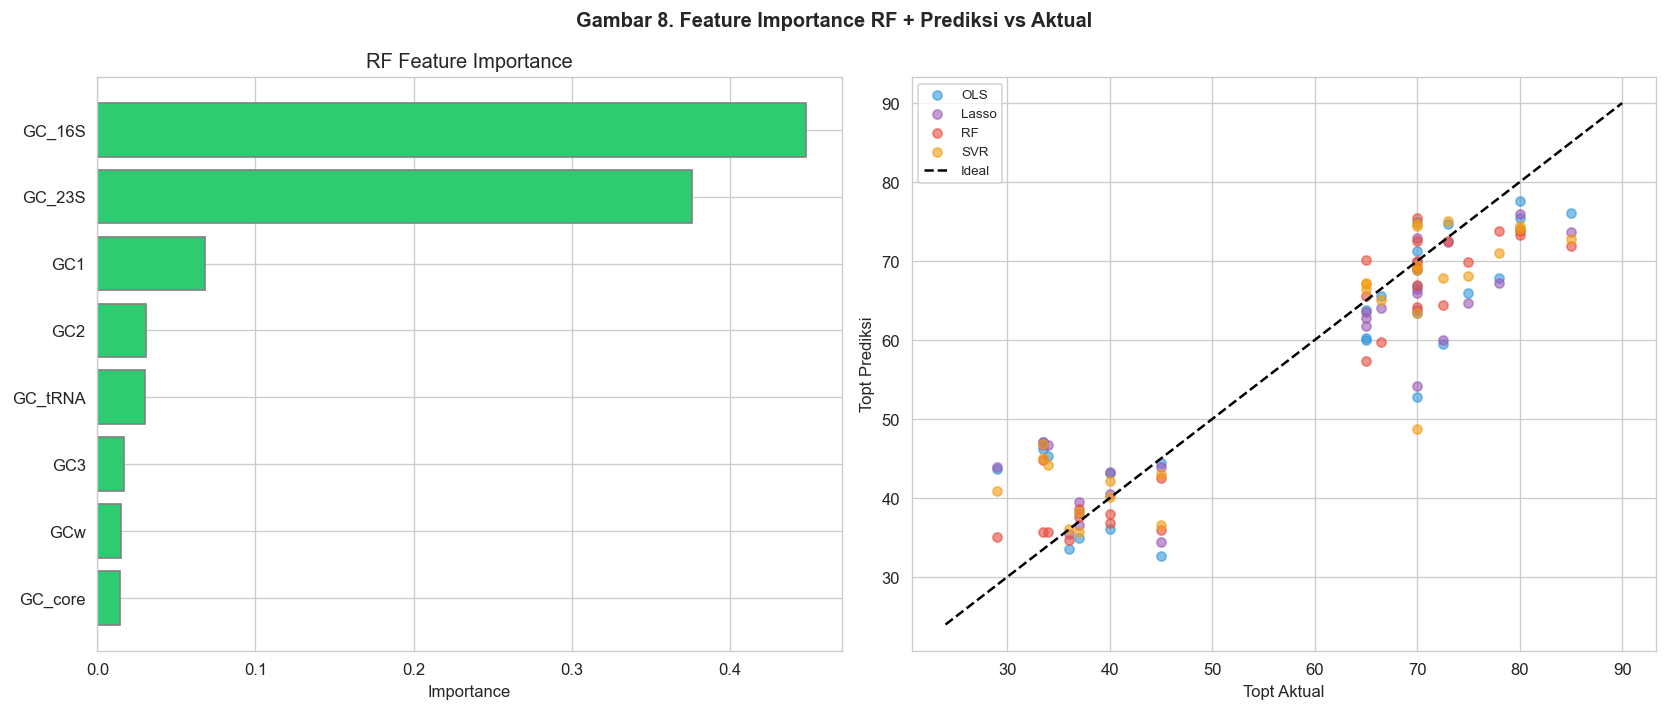

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Gambar 8. Feature Importance RF + Prediksi vs Aktual', fontweight='bold')

imp = best_rf.feature_importances_
idx = np.argsort(imp)
ax1.barh([ALL_FEATS[i] for i in idx], imp[idx], color='#2ECC71', edgecolor='grey')
ax1.set_xlabel('Importance'); ax1.set_title('RF Feature Importance')

for preds, lbl, col in [(y_pred_ols,'OLS','#3498DB'), (y_pred_lasso,'Lasso','#9B59B6'),
                         (y_pred_rf,'RF','#E74C3C'), (y_pred_svr,'SVR','#F39C12')]:
    ax2.scatter(y_te_r, preds, alpha=0.6, s=30, label=lbl, color=col)
lims = [y_te_r.min()-5, y_te_r.max()+5]
ax2.plot(lims, lims, 'k--', label='Ideal')
ax2.set_xlabel('Topt Aktual'); ax2.set_ylabel('Topt Prediksi'); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig8_model_comparison.png', bbox_inches='tight')
plt.show()

In [20]:
Xc_tv, Xc_te, yc_tv, yc_te = train_test_split(
    X, y_cls, test_size=0.30, random_state=42, stratify=y_cls)
Xc_tv_sc = scaler.fit_transform(Xc_tv)
Xc_te_sc = scaler.transform(Xc_te)

rfc_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators':[100,200], 'max_depth':[None,5,10]},
    cv=5, scoring='roc_auc', n_jobs=-1)
rfc_gs.fit(Xc_tv_sc, yc_tv)
best_rfc = rfc_gs.best_estimator_

y_pred_c = best_rfc.predict(Xc_te_sc)
y_prob_c = best_rfc.predict_proba(Xc_te_sc)[:,1]

acc   = accuracy_score(yc_te, y_pred_c)
f1    = f1_score(yc_te, y_pred_c)
auc   = roc_auc_score(yc_te, y_prob_c)
kappa = cohen_kappa_score(yc_te, y_pred_c)

print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print(f"Kappa    : {kappa:.4f}")

Accuracy : 0.9643
F1-Score : 0.9714
ROC-AUC  : 1.0000
Kappa    : 0.9239


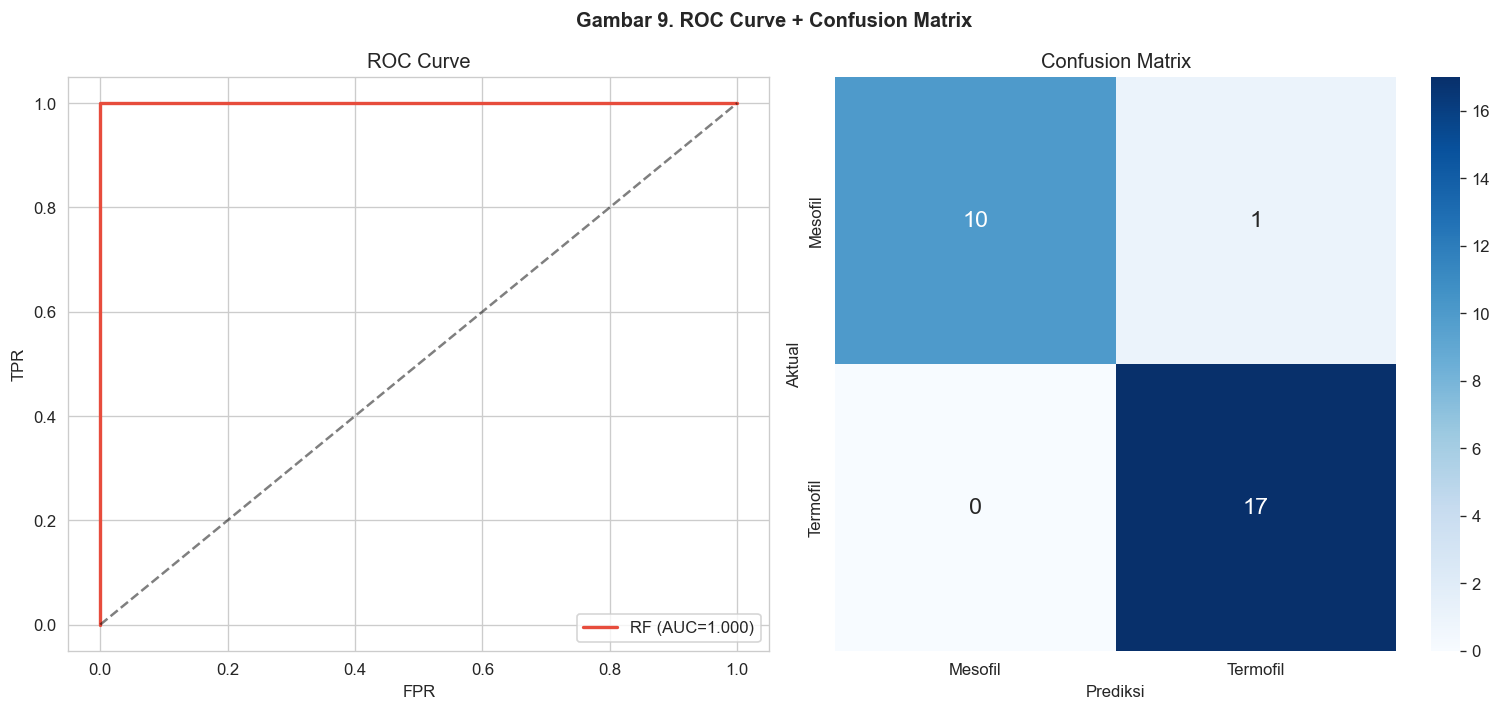

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Gambar 9. ROC Curve + Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(yc_te, y_prob_c)
ax1.plot(fpr, tpr, color='#E74C3C', lw=2, label=f'RF (AUC={auc:.3f})')
ax1.plot([0,1],[0,1],'k--', alpha=0.5)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve'); ax1.legend()

cm = confusion_matrix(yc_te, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Mesofil','Termofil'],
            yticklabels=['Mesofil','Termofil'], annot_kws={'size':14})
ax2.set_xlabel('Prediksi'); ax2.set_ylabel('Aktual')
ax2.set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('fig9_roc_cm.png', bbox_inches='tight')
plt.show()

  GCw       : AUC=0.6765
  GC_core   : AUC=0.7380
  GC_tRNA   : AUC=0.9037
  GC_16S    : AUC=0.9840
  GC_23S    : AUC=0.8984
  GC1       : AUC=0.6390
  GC2       : AUC=0.5027
  GC3       : AUC=0.5722


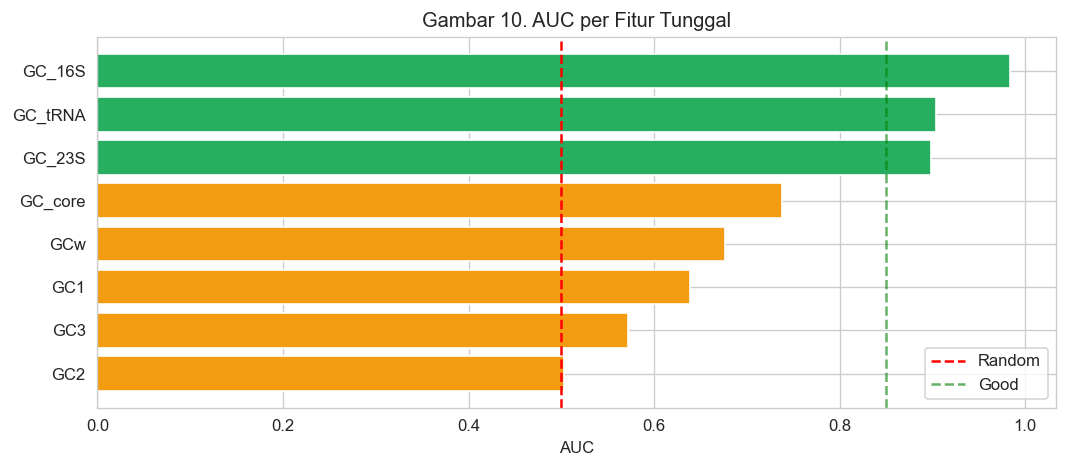

In [22]:
single_aucs = {}
for feat in ALL_FEATS:
    xi = df[[feat]].values; yi = y_cls
    Xi_tv, Xi_te, yi_tv, yi_te = train_test_split(xi, yi, test_size=0.3,
                                                    random_state=42, stratify=yi)
    rfc_s = RandomForestClassifier(n_estimators=100, random_state=42)
    rfc_s.fit(scaler.fit_transform(Xi_tv), yi_tv)
    prob_s = rfc_s.predict_proba(scaler.transform(Xi_te))[:,1]
    single_aucs[feat] = roc_auc_score(yi_te, prob_s)
    print(f"  {feat:<10}: AUC={single_aucs[feat]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
fs = sorted(single_aucs, key=lambda f: single_aucs[f])
ax.barh(fs, [single_aucs[f] for f in fs],
        color=['#27AE60' if single_aucs[f]>0.85 else '#F39C12' for f in fs])
ax.axvline(0.5, color='red', ls='--', label='Random')
ax.axvline(0.85, color='green', ls='--', alpha=0.6, label='Good')
ax.set_xlabel('AUC'); ax.legend()
ax.set_title('Gambar 10. AUC per Fitur Tunggal')
plt.tight_layout()
plt.savefig('fig10_single_auc.png', bbox_inches='tight')
plt.show()

In [23]:
print("=" * 75)
print("RINGKASAN HIPOTESIS")
print("=" * 75)

h1 = all(mw_res[f]['p'] < 0.05 for f in ['GC_tRNA','GC_16S','GC_23S'])
print(f"\nH1 (perbedaan GC RNA termofil vs mesofil signifikan): {'DITERIMA' if h1 else 'DITOLAK'}")
for f in ['GC_tRNA','GC_16S','GC_23S']:
    print(f"   {f}: p={mw_res[f]['p']:.2e} {mw_res[f]['sig']}")

h2 = all(abs(corr_res[f]['pearson']) > abs(corr_res['GCw']['pearson'])
         for f in ['GC_tRNA','GC_16S','GC_23S'])
print(f"\nH2 (GC RNA korelasi lebih kuat dari GCw): {'DITERIMA' if h2 else 'DITOLAK'}")
for f in GC_FEATS:
    print(f"   {f}: r={corr_res[f]['pearson']:.3f}")

h3 = rmse_rf <= 12
print(f"\nH3 (RF RMSE <= 12C): {'DITERIMA' if h3 else 'DITOLAK'} (RMSE={rmse_rf:.2f}C)")

h4 = auc >= 0.85
print(f"\nH4 (AUC >= 0.85): {'DITERIMA' if h4 else 'DITOLAK'} (AUC={auc:.4f})")

RINGKASAN HIPOTESIS

H1 (perbedaan GC RNA termofil vs mesofil signifikan): DITERIMA
   GC_tRNA: p=3.50e-07 ***
   GC_16S: p=2.87e-13 ***
   GC_23S: p=2.69e-12 ***

H2 (GC RNA korelasi lebih kuat dari GCw): DITERIMA
   GCw: r=-0.223
   GC_core: r=-0.216
   GC_tRNA: r=0.561
   GC_16S: r=0.795
   GC_23S: r=0.749

H3 (RF RMSE <= 12C): DITERIMA (RMSE=5.52C)

H4 (AUC >= 0.85): DITERIMA (AUC=1.0000)
